In [1]:
import matplotlib.pyplot as plt
import json
import os

def draw_scatter_all_batch(result_list: list,
                           x_col = 19, y_col=9,
                           y_label = 'y_label', 
                           x_title = "mean_difference", y_title = "acc",
                           result_path = "./result_fig", figname = "test.png",
                           save_fig = True,
                           x_data_dict = {},
                           y_data_dict = {},
                           ):
    # Create a new figure
    # plt.figure()

    # scatter
    # Extract the metric column as x
    x = [row[x_col] for row in result_list]
    x_max = max(abs(x) for x in x)
    x = [x_i/x_max for x_i in x]

    # x_data_dict
    x_data_dict[y_label] = x

    # Extract the acc columns as y
    y = [row[y_col] for row in result_list]

    # y_data_dict
    y_data_dict[y_label] = y

    size_point = max(2, min(1000.0/len(x), 20))
    print(f"draw_scatter(): size_point = {size_point}")
    
    plt.scatter(x, y, label=y_label, s=size_point, alpha=0.8)

    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # title
    plt.xlabel(x_title)
    plt.ylabel(y_title)

    # save the plot
    # plt.show()
    if save_fig:
        # test_path_exist(result_path)
        plt.savefig(os.path.join(result_path, figname), bbox_inches='tight')

    # Close the figure
    # plt.close()   

def mean_scatter(x_list: list,
                            y_list: list,
                           x_col = 19, y_col=9,
                           y_label = 'y_label', 
                           x_title = "mean_difference", y_title = "acc",
                           result_path = "./result_fig", figname = "test.png",
                           save_fig = True,
                           ):
    # Create a new figure
    # plt.figure()
    x = [row[x_col] for row in x_list]
    y = [row[y_col] for row in y_list]
    size_point = max(2, min(1000.0/len(x), 20))
    plt.scatter(x, y, label=y_label, s=size_point, alpha=0.8)
    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    # title
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    # plt.show()

In [2]:
# task_name 
# cross-region: dwq_s2_xj_s2, dwq_l8_xj_l8
# cross-sensor: dwq_s2_dwq_l8, xj_s2_xj_l8
task_transfer_list = ["dwq_s2_xj_s2", "dwq_l8_xj_l8", "dwq_s2_dwq_l8", "xj_s2_xj_l8"]

binary_class_index_list_dict = {"dwq_s2_xj_s2": [1, 2, 3, 6, 7, 8],
                                "dwq_s2_dwq_l8": [1, 2, 6, 7, 8],
                                "dwq_l8_xj_l8": [1, 6, 7, 8],
                                "xj_s2_xj_l8": [1, 3, 5, 6, 7, 8]}

# dwq_sentinel2, dwq_landsat8, xj_sentinel2, xj_landsat8
dataset_name_source_list_dict = {"dwq_s2_xj_s2": ["dwq_sentinel2", "xj_sentinel2"],
                                "dwq_s2_dwq_l8": ["dwq_sentinel2", "dwq_landsat8"],
                                "dwq_l8_xj_l8": ["dwq_landsat8", "xj_landsat8"],
                                "xj_s2_xj_l8": ["xj_sentinel2", "xj_landsat8"]}

dataset_i_list = [0, 1]

task_transfer = task_transfer_list[0]

def draw(task_transfer : str = "dwq_s2_xj_s2",
         i : int = 1,
         date_prefix : str = "20241218_2004",
         ):
    binary_class_index_list = binary_class_index_list_dict[task_transfer]
    dataset_name_source_list = dataset_name_source_list_dict[task_transfer]
    dataset_name_target_list = dataset_name_source_list[::-1]

    # batch size
    batch_size = 4

    # E:\Yiling\at_SIAT_research\z_result\20241210_transfer_metric_FD_cross_sensor_batch14_FD\20241210_1734_1_dwq_s2_xj_s2_\4_label1_FID_all-batch1_100img
    # 8_label1_FID_all-batch4_100img
    result_path = fr"E:\Yiling\at_SIAT_research\z_result\20241210_transfer_metric_FD_cross_sensor_batch14_FD\20241210_1734_{i}_{task_transfer}_\8_label1_FID_all-batch4_100img"
    result_list_dict_path = os.path.join(result_path, f"result_list_dict_{dataset_name_source_list[0]}-{dataset_name_source_list[1]}_batch{batch_size}.json")
    with open(result_list_dict_path, 'r') as f:
        result_list_dict = json.load(f)
    result_list_name_path = os.path.join(result_path, "result_list_name.json")
    with open(result_list_name_path, 'r') as f:
        result_list_name = json.load(f)

    for i in range(len(result_list_name)):
        print(f"{i}, {result_list_name[i]}")

    # draw_scatter_all_batch
    x_data_dict = {}
    y_data_dict = {}
    # Create a new figure
    metric_i = 13
    accuracy_i = 5
    binary_class_name_list = ["background", "Cropland", "Forest", "Grassland", "Shrubland", "Wetland", "Water", "Built-up", "Bareland"]
    plt.figure()
    for dataset_i in dataset_i_list:
        save_fig = False
        for binary_class_index in binary_class_index_list:
            result_list = result_list_dict[dataset_name_source_list[dataset_i] + f"_cls_{binary_class_index}"]
            # save the last figure
            if binary_class_index == binary_class_index_list[-1]:
                save_fig = True
            draw_scatter_all_batch(result_list, x_col=metric_i, y_col=accuracy_i,
                                    y_label=f"{dataset_name_source_list[dataset_i]}-{dataset_name_target_list[dataset_i]}_cls-{binary_class_index}-{binary_class_name_list[binary_class_index]}",
                                    x_title=result_list_name[metric_i], y_title=result_list_name[accuracy_i],
                                    # result_path=os.path.join("./result_fig", "fig"),
                                    figname=f"{date_prefix}_scatter_{task_transfer}_batch{batch_size}_cls_{binary_class_index}_{dataset_i}.png",
                                    save_fig=save_fig,
                                    x_data_dict=x_data_dict,
                                    y_data_dict=y_data_dict,
                                    )
    # plt.close()


    # 度量分数与精度损失的分布关系
    # mean, std, max, min, median, 25%, 75%
    x_mean_list = []
    y_mean_list = []
    for key, value in x_data_dict.items():
        x_mean_list.append([key, sum(value)/len(value)])
    for key, value in y_data_dict.items():
        y_mean_list.append([key, sum(value)/len(value)])
    print(f"x_mean_list: {x_mean_list}")
    print(f"y_mean_list: {y_mean_list}")

    plt.figure()
    for i in range(len(x_mean_list)):
        mean_scatter([x_mean_list[i]], [y_mean_list[i]], x_col=1, y_col=1, y_label=x_mean_list[i][0], x_title="x_mean", y_title="y_mean")
    x = [-0.3, 1.0]
    plt.plot(x, x, label='x=y', linestyle='--', color='red')
    # plt.show()
    plt.savefig(os.path.join("./result_fig", f"{date_prefix}_mean_{task_transfer}_batch{batch_size}.png"), bbox_inches='tight')

0, source
1, target
2, class_index
3, class_name
4, OA_delta
5, F1_delta
6, precision_delta
7, mean_dif_absolute_sum
8, mean_dif_absolute_abs_sum
9, mean_dif_relative_sum
10, mean_dif_relative_abs_sum
11, mean_dif_absolute_y0_y1_diff
12, mean_dif_absolute_abs_y0_y1_diff
13, mean_dif_relative_y0_y1_diff
14, mean_dif_relative_abs_y0_y1_diff
15, mean_dif_absolute_y0_y1_diff_abs
16, mean_dif_absolute_abs_y0_y1_diff_abs
17, mean_dif_relative_y0_y1_diff_abs
18, mean_dif_relative_abs_y0_y1_diff_abs
19, mean_dif_absolute_y0_y1_diff_normalized
20, mean_dif_absolute_abs_y0_y1_diff_normalized
21, mean_dif_relative_y0_y1_diff_normalized
22, mean_dif_relative_abs_y0_y1_diff_normalized
23, mean_dif_absolute_y0_y1_diff_abs_normalized
24, mean_dif_absolute_abs_y0_y1_diff_abs_normalized
25, mean_dif_relative_y0_y1_diff_abs_normalized
26, mean_dif_relative_abs_y0_y1_diff_abs_normalized
27, FD_sum
28, FD_y0_y1_diff
29, FD_y0_y1_diff_abs
30, FD_y0_y1_diff_normalized
31, FD_y0_y1_diff_abs_normalized
draw_s

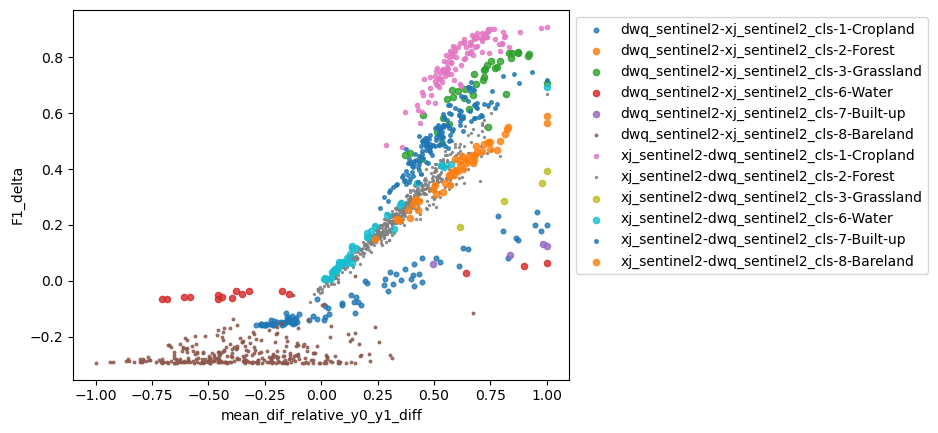

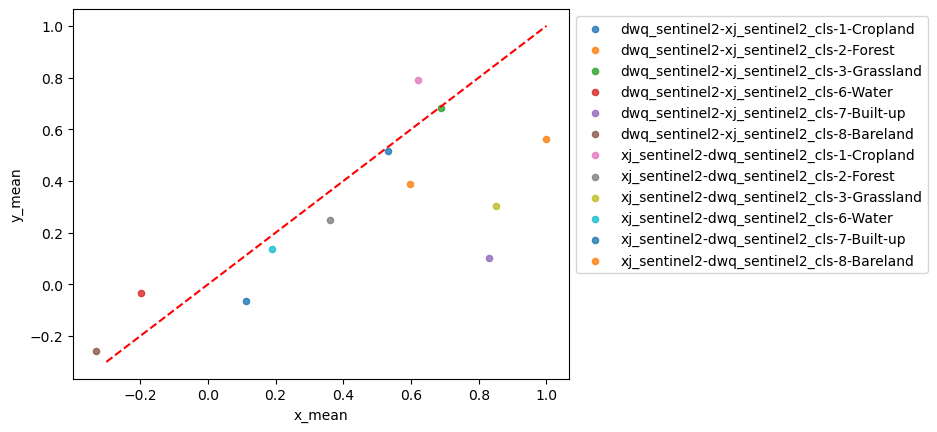

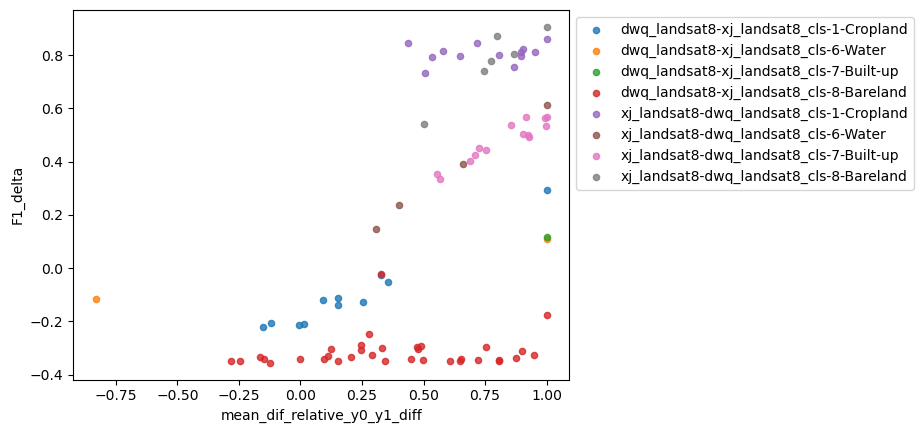

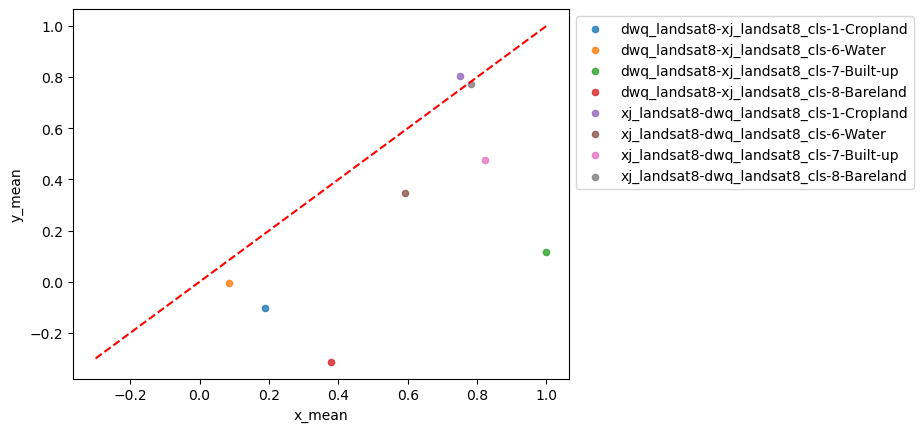

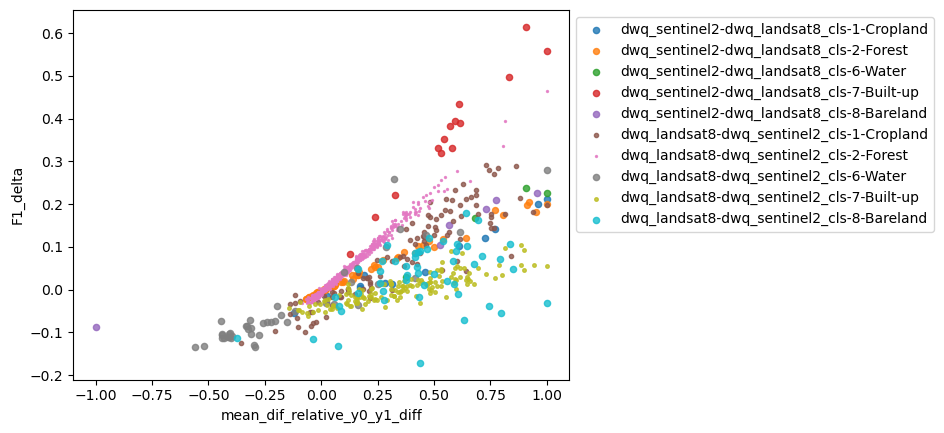

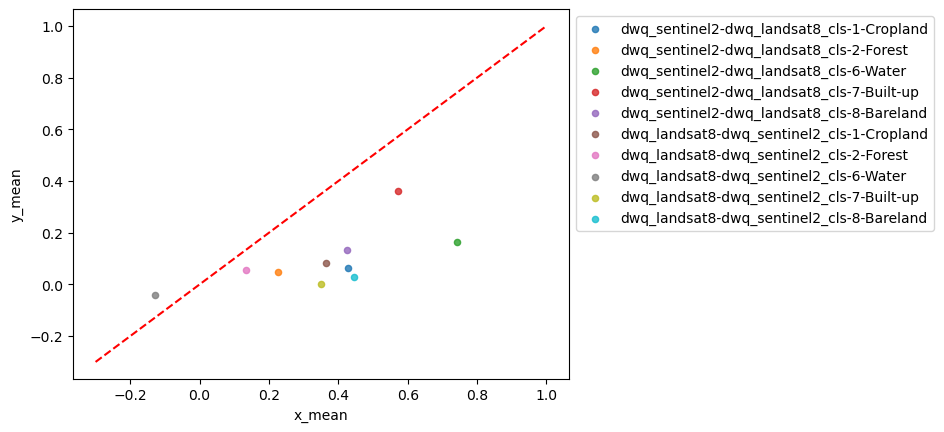

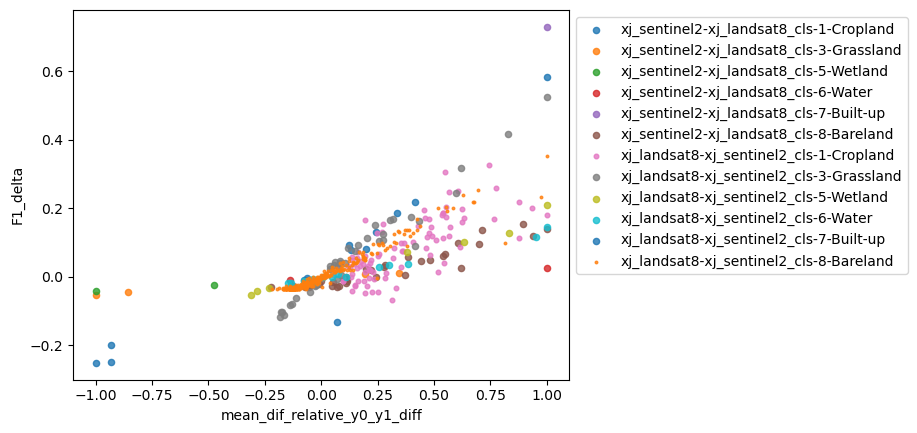

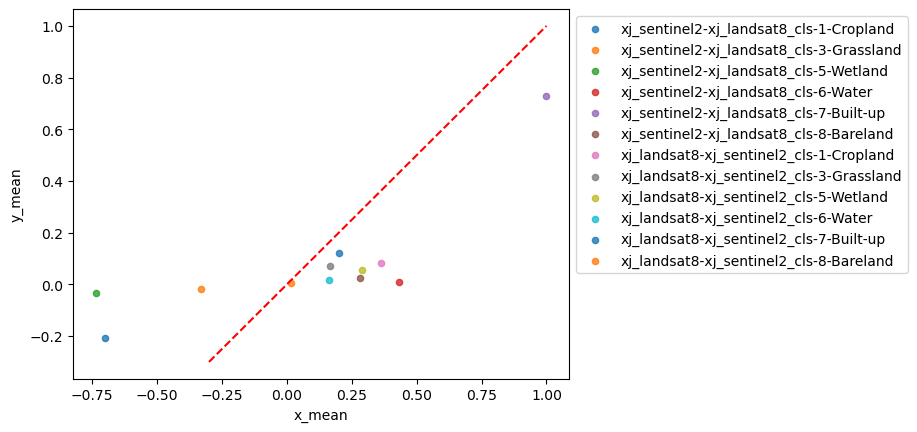

In [3]:
date_prefix = "20241219_1430"
for i, task_name in enumerate(task_transfer_list):
    draw(task_transfer=task_name, i=i+1, date_prefix=date_prefix)